## **Unemployment in the UK**

The author gives the example of official unemployment statistics.  
The government never just says "2 million." They say "about 2 million,  
plus or minus 50,000."  

**Margin of Error:** This is an admission that our sample is not perfect.  
**Uncertainty Interval:** The range of values ​​within which we hope the true number lies.

C:\Users\dimal\AppData\Local\Temp\ipykernel_12056\1899096110.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


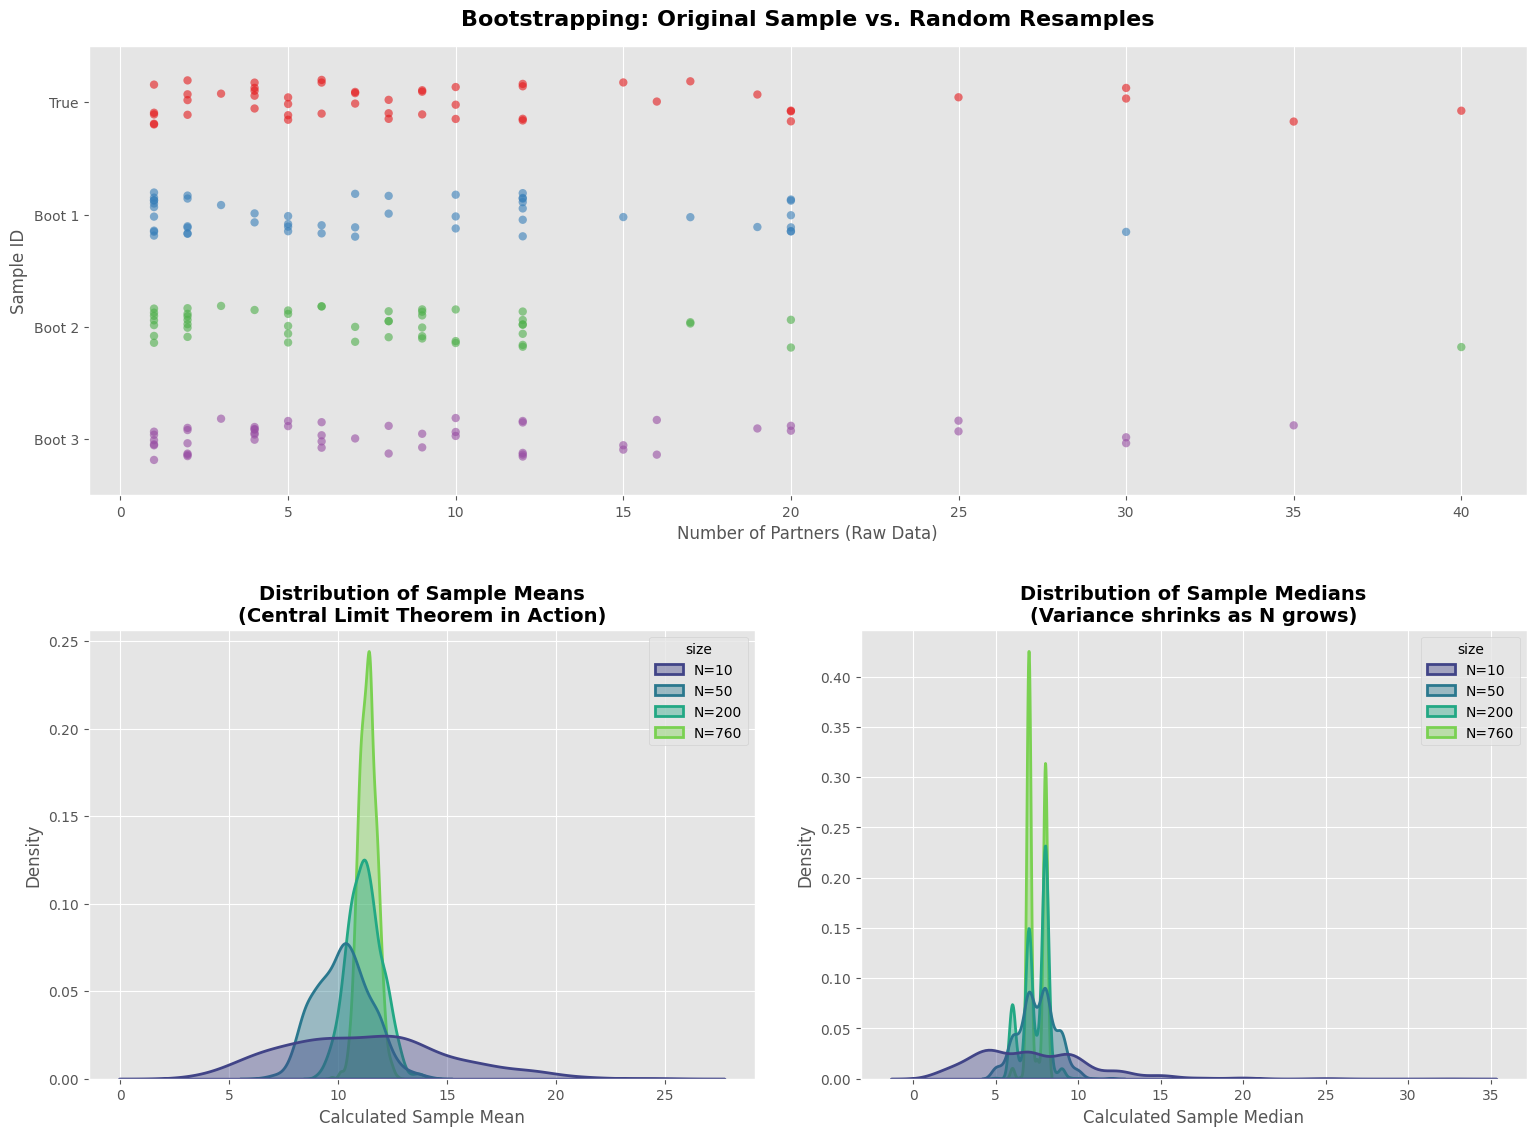

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set ggplot style for an R-like appearance
plt.style.use('ggplot')

#1. LOAD AND PREPARE THE DATA
# df_boot contains the raw values for True Sample and Bootstrap resamples
df_boot = pd.read_csv('7-2-datasnatch.csv')

# df_dist contains the means and medians for different sample sizes (N)
df_dist = pd.read_csv('7-3-datasnatch.csv')

# Clean up any potential unnamed index columns that pandas might pick up
df_boot = df_boot.loc[:, ~df_boot.columns.str.contains('^Unnamed')]
df_dist = df_dist.loc[:, ~df_dist.columns.str.contains('^Unnamed')]

# Define the logical order of sample sizes for plotting
size_order = ['N=10', 'N=50', 'N=200', 'N=760']


# 2. CREATE THE DASHBOARD LAYOUT
# We create a layout where the Bootstrapping plot is on top (spanning full width),
# and the Means/Medians distributions are side-by-side on the bottom.
fig = plt.figure(figsize=(16, 12))
ax1 = plt.subplot(2, 1, 1) # Top row, full width
ax2 = plt.subplot(2, 2, 3) # Bottom row, left
ax3 = plt.subplot(2, 2, 4) # Bottom row, right


# PLOT 1: Bootstrapping (Original vs Resamples)
# A strip plot (dot plot) shows the individual data points for each sample
sns.stripplot(
    data=df_boot, 
    x='partners', 
    y='sampleid', 
    hue_order=size_order, 
    jitter=0.2, # Spread points vertically so they don't overlap completely
    alpha=0.6, 
    size=6,
    palette='Set1',
    ax=ax1
)

ax1.set_title('Bootstrapping: Original Sample vs. Random Resamples', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Number of Partners (Raw Data)', fontsize=12)
ax1.set_ylabel('Sample ID', fontsize=12)


# PLOT 2: Distribution of Sample Means (Central Limit Theorem)
# KDE (Kernel Density Estimate) plots create smooth curves representing histograms
sns.kdeplot(
    data=df_dist, 
    x='means', 
    hue='size', 
    hue_order=size_order, 
    fill=True, 
    alpha=0.4, 
    linewidth=2,
    palette='viridis', # Beautiful color scale showing progression
    ax=ax2
)

ax2.set_title('Distribution of Sample Means\n(Central Limit Theorem in Action)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Calculated Sample Mean', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)


# PLOT 3: Distribution of Sample Medians
sns.kdeplot(
    data=df_dist, 
    x='medians', 
    hue='size', 
    hue_order=size_order, 
    fill=True, 
    alpha=0.4, 
    linewidth=2,
    palette='viridis',
    ax=ax3
)

ax3.set_title('Distribution of Sample Medians\n(Variance shrinks as N grows)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Calculated Sample Median', fontsize=12)
ax3.set_ylabel('Density', fontsize=12)

# 3. FINAL ADJUSTMENTS AND DISPLAY
plt.tight_layout(pad=3.0)
plt.show()

## **Bootstrapping: Statistical "pull yourself up by the hair"**

This is a revolutionary idea. How do we know the accuracy of our estimate  
if we only have one sample?  
Imagine that your sample (say, 100 people) is the entire world.  

**The Bootstrap Process:**

We take our sample.  
We draw from it a "new" sample of the same size, but with replacement.  
That is, we can draw the same person several times, and not draw someone at all.  
We calculate the average for this new sample.  
We repeat this 10,000 times on the computer.  

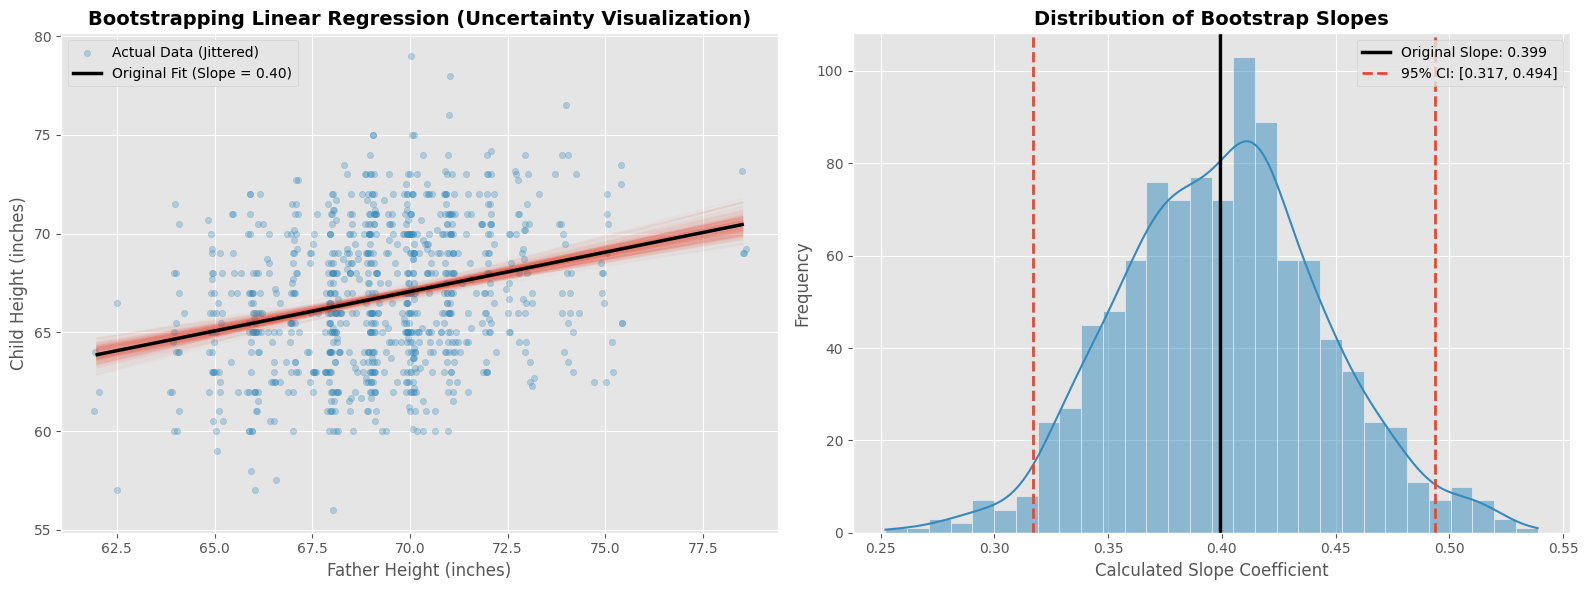

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set ggplot style for an R-like appearance
plt.style.use('ggplot')

# 1. LOAD DATA
df = pd.read_csv('7-4-galton-x.csv')

# We will predict Child's Height (Y) based on Father's Height (X)
X = df['Father'].values
Y = df['Height'].values

# Calculate the Original (True) Regression Line
m_orig, b_orig = np.polyfit(X, Y, 1)


# 2. PERFORM BOOTSTRAPPING
n_iterations = 1000  # Number of bootstrap samples
n_size = len(X)
slopes = []
intercepts = []

np.random.seed(13) # For reproducibility

for _ in range(n_iterations):
    # Resample with replacement
    indices = np.random.choice(range(n_size), size=n_size, replace=True)
    X_resampled = X[indices]
    Y_resampled = Y[indices]
    
    # Fit regression for the resampled data
    m, b = np.polyfit(X_resampled, Y_resampled, 1)
    slopes.append(m)
    intercepts.append(b)

# Calculate 95% Confidence Interval for the slope
slope_lower = np.percentile(slopes, 2.5)
slope_upper = np.percentile(slopes, 97.5)

# 3. VISUALIZATION DASHBOARD
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PLOT 1: Scatter plot with Bootstrap Lines
# Plot a tiny bit of jittered data so overlapping points are visible
jitter_x = X + np.random.normal(0, 0.1, size=n_size)
axes[0].scatter(jitter_x, Y, alpha=0.3, color='#348ABD', s=20, label='Actual Data (Jittered)')

# Draw 200 random bootstrap lines (drawing all 1000 makes it too solid)
x_line = np.array([X.min(), X.max()])
for i in range(200):
    y_line = slopes[i] * x_line + intercepts[i]
    # Faint red lines to show uncertainty
    axes[0].plot(x_line, y_line, color='#E24A33', alpha=0.03, zorder=1)

# Draw the main original regression line on top
y_orig_line = m_orig * x_line + b_orig
axes[0].plot(x_line, y_orig_line, color='black', linewidth=2.5, 
             label=f'Original Fit (Slope = {m_orig:.2f})', zorder=5)

axes[0].set_title('Bootstrapping Linear Regression (Uncertainty Visualization)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Father Height (inches)', fontsize=12)
axes[0].set_ylabel('Child Height (inches)', fontsize=12)
axes[0].legend(loc='upper left')


# PLOT 2: Distribution of Bootstrap Slopes
sns.histplot(slopes, bins=30, color='#348ABD', kde=True, ax=axes[1])

# Highlight the original slope
axes[1].axvline(m_orig, color='black', linestyle='-', linewidth=2.5, 
                label=f'Original Slope: {m_orig:.3f}')

# Highlight the 95% Confidence Interval boundaries
axes[1].axvline(slope_lower, color='#E24A33', linestyle='--', linewidth=2, 
                label=f'95% CI: [{slope_lower:.3f}, {slope_upper:.3f}]')
axes[1].axvline(slope_upper, color='#E24A33', linestyle='--', linewidth=2)

axes[1].set_title('Distribution of Bootstrap Slopes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Calculated Slope Coefficient', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()

# FINAL ADJUSTMENTS
plt.tight_layout()
plt.show()

## **Why does it work?**

When we do these 10,000 repetitions, we will get 10,000 different means.  
If we plot them on a histogram, it will almost always be shaped like a "bell"   
(Normal Distribution).  

The center of this bell is our initial mean.  
The width of this bell tells us how much we are "floating" in our estimates.  
If the bell is narrow, we are very confident. If it is wide, our data is very unstable.  

## **Summary**

**No complex math needed:**  
This used to require complex formulas. Today, all we need is computer power.  
**Resampling:**
This is the heart of modern data analysis. We “shuffle” what we have to see  
how much randomness affects the result.  
**Intervals are key:**
Spiegelhalter insists that no number should be published without an assessment  
of its accuracy. Without an interval, the number is meaningless.